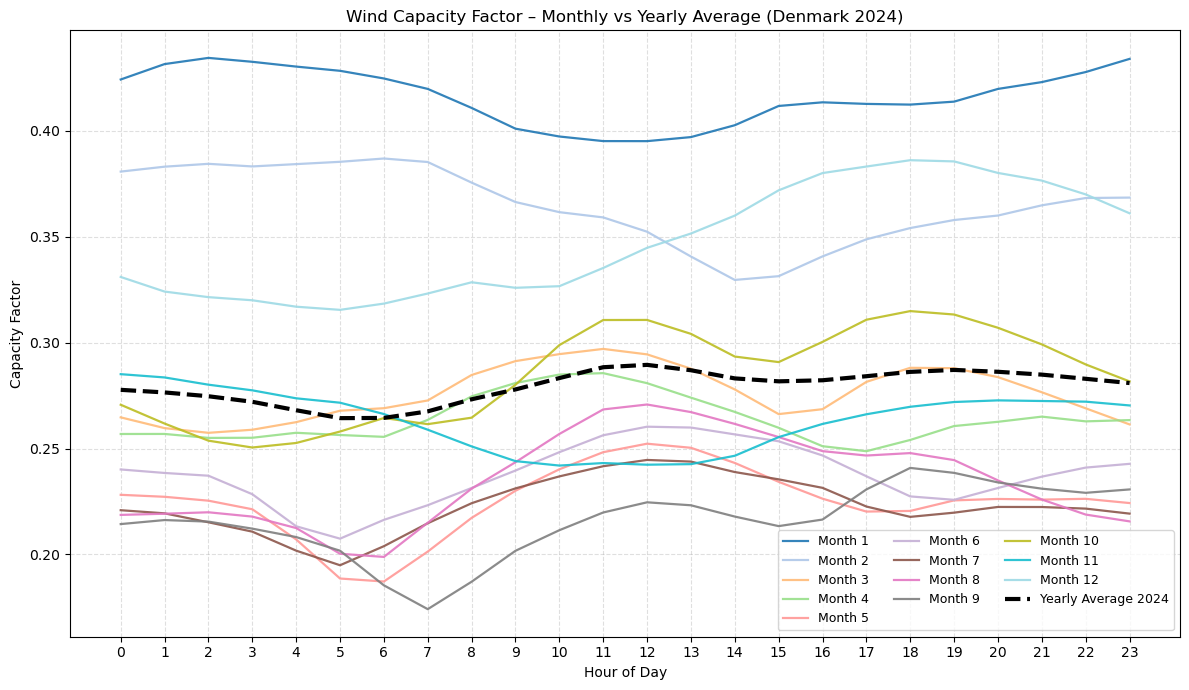

Deterministic wind profile exported successfully.


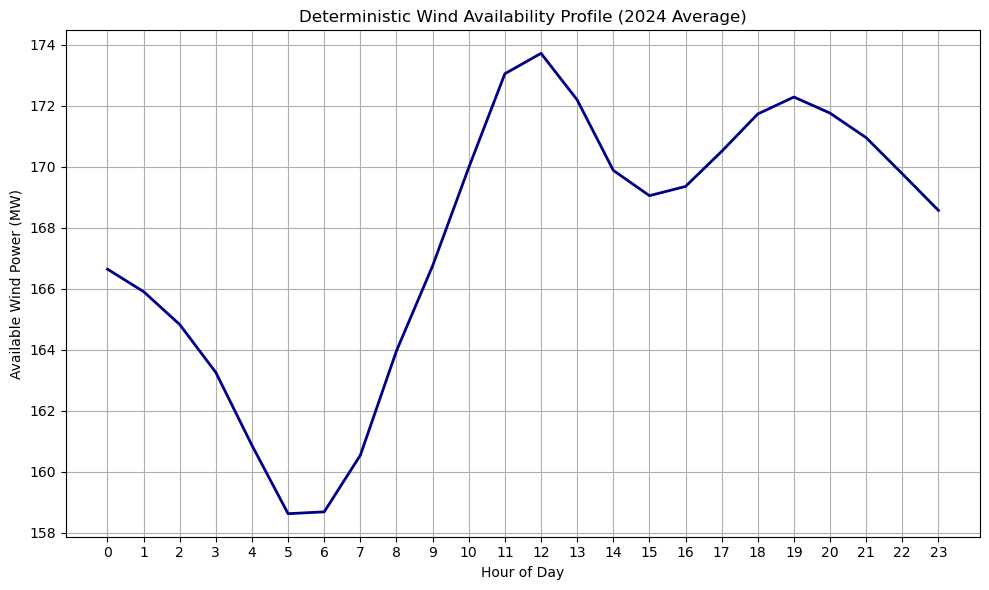

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================
# USER SETTINGS
# ============================================

BASE_DIR = os.path.dirname(os.getcwd())  # if notebook inside notebooks/
DATA_DIR = os.path.join(BASE_DIR, "data", "raw", "NinjaRaw")

wind_file = os.path.join(DATA_DIR, "ninja-wind-country-DK-current_onshore-merra2.csv")

df = pd.read_csv(wind_file, skiprows=3)
df["time"] = pd.to_datetime(df["time"])

# Filter year 2024
df_2024 = df[df["time"].dt.year == 2024].copy()
df_2024["hour"] = df_2024["time"].dt.hour
df_2024["month"] = df_2024["time"].dt.month

# ============================================
# 2. COMPUTE HOURLY AVERAGES (CAPACITY FACTOR)
# ============================================

# Yearly hourly average
yearly_avg = (
    df_2024
    .groupby("hour")["NATIONAL"]
    .mean()
    .reset_index()
    .rename(columns={"NATIONAL": "capacity_factor"})
)

# Monthly hourly averages
monthly_avg = (
    df_2024
    .groupby(["month", "hour"])["NATIONAL"]
    .mean()
    .reset_index()
)

# ============================================
# 3. PLOT MONTHLY + YEARLY AVERAGE (CAPACITY FACTOR)
# ============================================

plt.figure(figsize=(12, 7))

colors = plt.cm.tab20(np.linspace(0, 1, 12))

for m in range(1, 13):
    data_m = monthly_avg[monthly_avg["month"] == m]
    plt.plot(
        data_m["hour"],
        data_m["NATIONAL"],
        color=colors[m-1],
        linewidth=1.6,
        alpha=0.9,
        label=f"Month {m}"
    )

# Yearly average (highlighted)
plt.plot(
    yearly_avg["hour"],
    yearly_avg["capacity_factor"],
    linewidth=3,
    linestyle="--",
    color="black",
    label="Yearly Average 2024"
)

plt.xlabel("Hour of Day")
plt.ylabel("Capacity Factor")
plt.title("Wind Capacity Factor – Monthly vs Yearly Average (Denmark 2024)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 4. SCALE TO INSTALLED CAPACITY
# ============================================

yearly_avg["available_wind_MW"] = (
    yearly_avg["capacity_factor"] * INSTALLED_WIND_CAPACITY
)

# ============================================
# 5. EXPORT DETERMINISTIC WIND PROFILE
# ============================================

yearly_avg.to_csv("wind_capacity_factor_2024_avg.csv", index=False)

yearly_avg[["hour", "available_wind_MW"]].to_csv(
    "wind_available_power_2024_avg_MW.csv",
    index=False
)

print("Deterministic wind profile exported successfully.")

# ============================================
# 6. PLOT FINAL DETERMINISTIC PROFILE (MW)
# ============================================

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_avg["hour"],
    yearly_avg["available_wind_MW"],
    linewidth=2,
    color="darkblue"
)

plt.xlabel("Hour of Day")
plt.ylabel("Available Wind Power (MW)")
plt.title("Deterministic Wind Availability Profile (2024 Average)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()